# Pulling Data


Bajamos la información directamente de Kaggle, usando la API 

In [3]:
import os
import requests
from getpass import getpass
from kaggle.api.kaggle_api_extended import KaggleApi

kaggle_token = os.getenv("KAGGLE_API_TOKEN")
api = KaggleApi()
api.authenticate()

try:
    api.competition_download_file(
        "house-prices-advanced-regression-techniques",
        "train.csv",
        path="./"
    )
except requests.HTTPError as error:
    
    raise

HTTPError: 401 Client Error: Unauthorized for url: https://api.kaggle.com/v1/competitions.CompetitionApiService/DownloadDataFile

# Exploración Inicial

In [4]:
import pandas as pd

pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)

train_df = pd.read_csv("train.csv")
print("Train dataset shape:", train_df.shape)
print("Train dataset columns:", train_df.columns)
print("Train dataset Variables Predictoras Posibles:", train_df.shape[1]-2) # id y target
print("Train dataset Variables Objetivo:", 1, ": Precio de Venta") # target
print("Train dataset Datos de Entrenamiento:", train_df.shape[0]) 
print("Train dataset head:")
train_df.head()


Train dataset shape: (1460, 81)
Train dataset columns: Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'Gara

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


## Datos Faltantes


In [5]:
train_df.info()

missing_summary = (
    train_df.isna()
    .sum()
    .to_frame(name="datos_faltantes")
    .assign(
        porcentaje_faltante=lambda dataframe: (
            dataframe["datos_faltantes"] / len(train_df) * 100
        ).round(2)
    )
    .sort_values("porcentaje_faltante", ascending=False)
 )

missing_summary[missing_summary["datos_faltantes"] > 0]

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

,datos_faltantes,porcentaje_faltante
PoolQC,1453,99.52
MiscFeature,1406,96.30
Alley,1369,93.77
Fence,1179,80.75
MasVnrType,872,59.73
FireplaceQu,690,47.26
LotFrontage,259,17.74
GarageYrBlt,81,5.55
GarageCond,81,5.55
GarageType,81,5.55


## Observacion individual de columnas tipo texto

In [54]:
c="GarageFinish"
train_df[c].value_counts()

GarageFinish
Unf    605
RFn    422
Fin    352
Name: count, dtype: int64

## Observar Distribución de Variables Cualitivativas de V. Objetivo

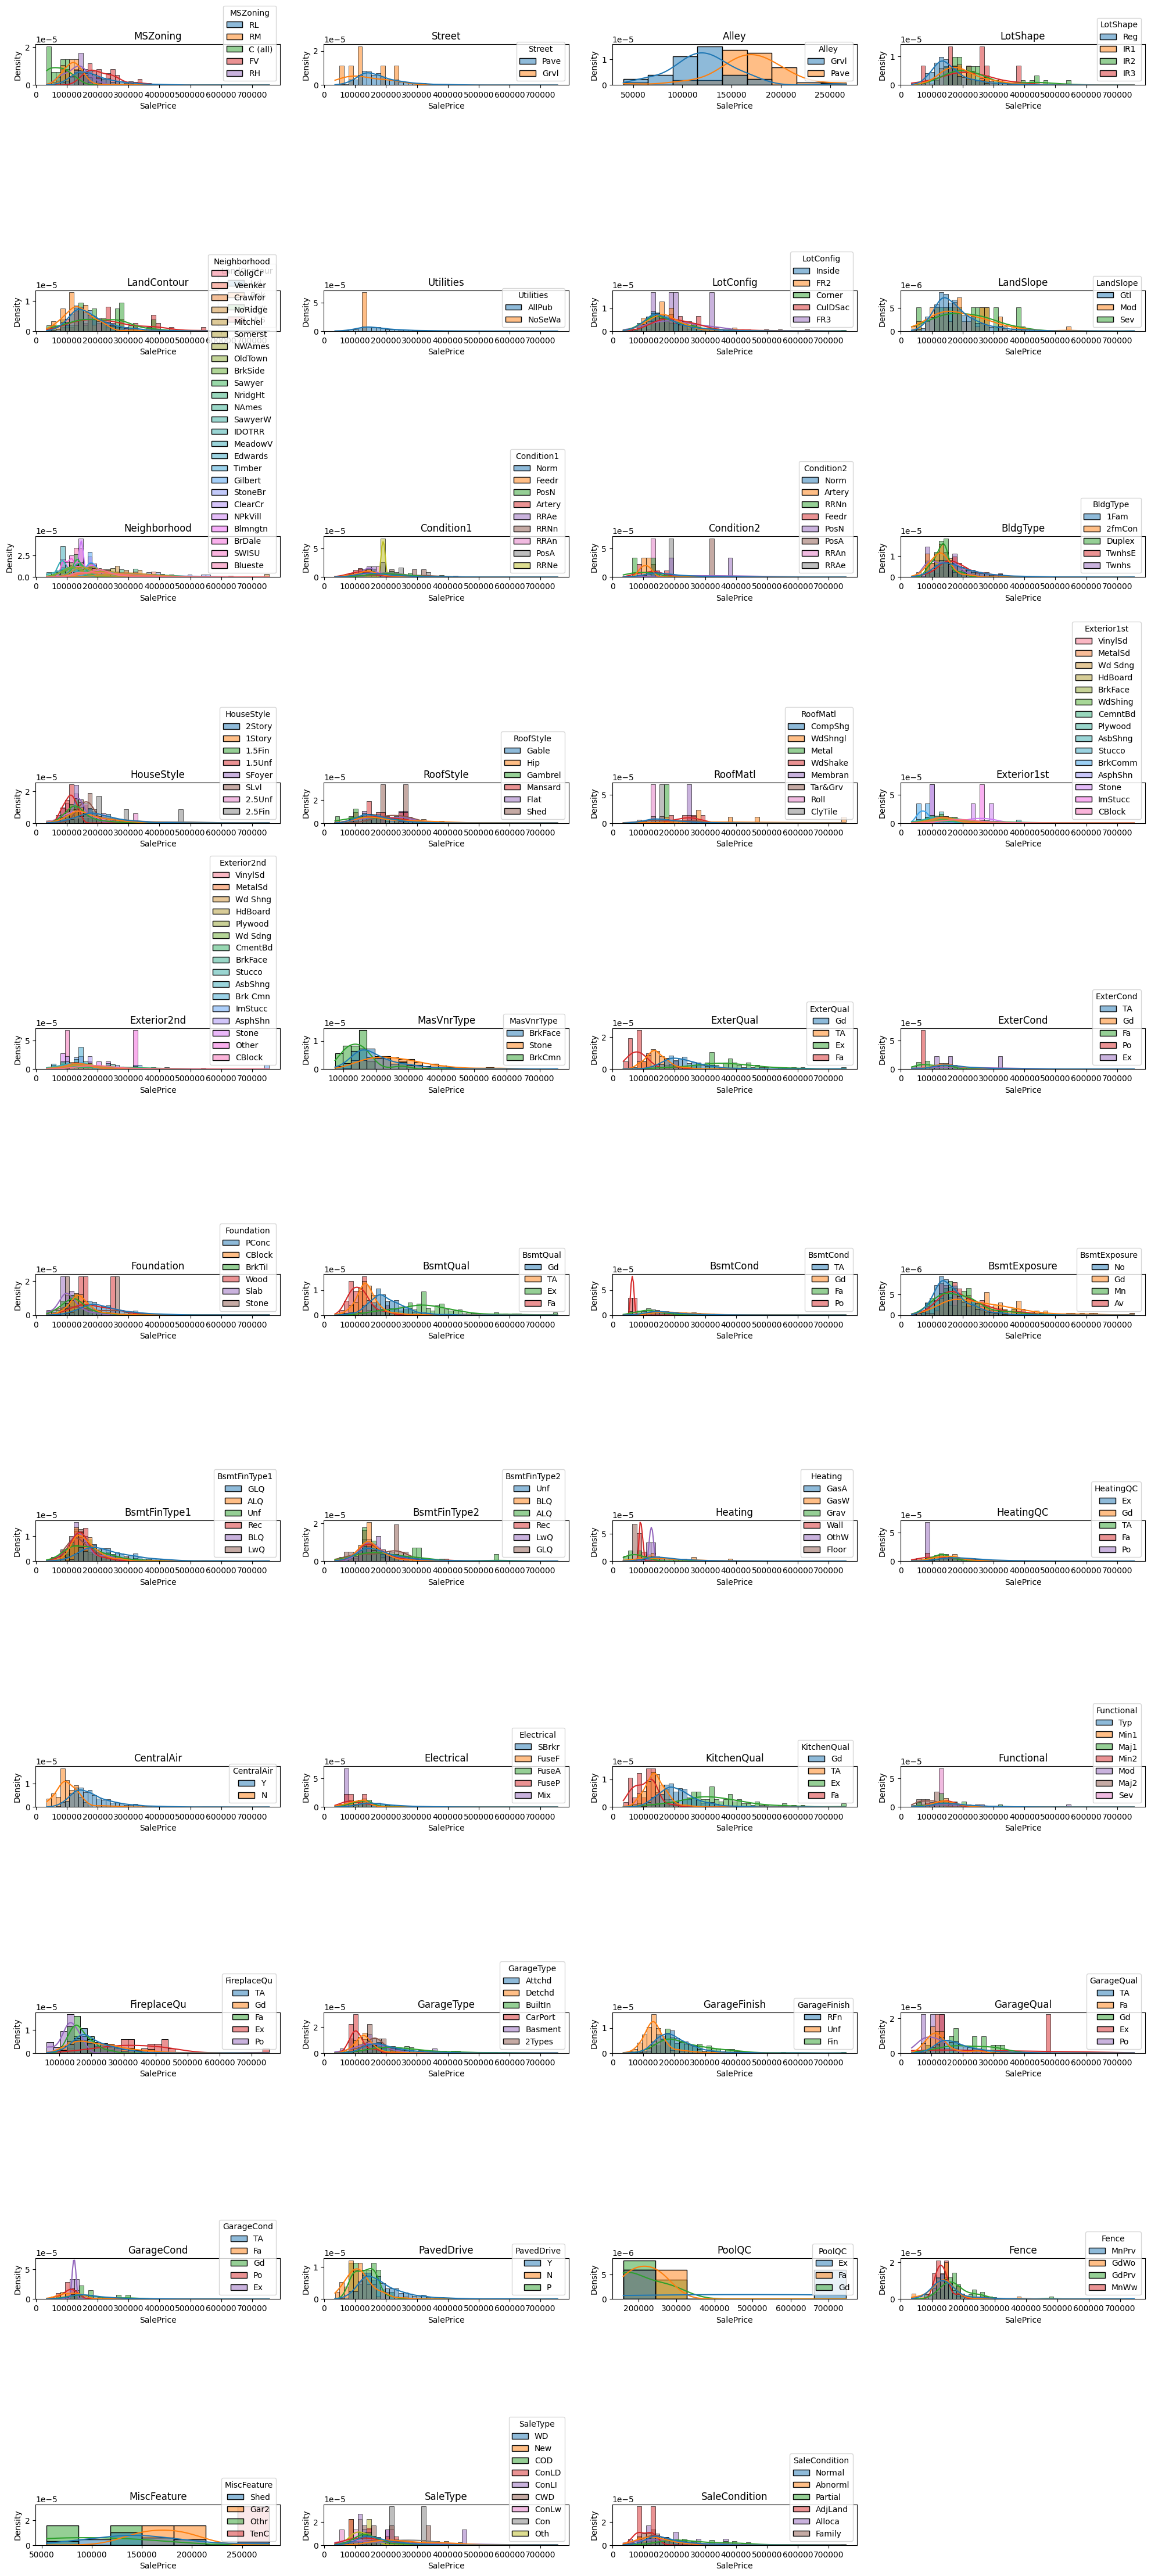

In [ ]:



import math
import matplotlib.pyplot as plt
import seaborn as sns

categorical_columns = train_df.select_dtypes(include="object").columns.tolist()

n_cols = 4
n_rows = math.ceil(len(categorical_columns) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
axes = axes.flatten()

for ax, column in zip(axes, categorical_columns):
    sns.histplot(
        data=train_df,
        x="SalePrice",
        hue=column,
        kde=True,
        stat="density",
        common_norm=False,
        ax=ax,
    )
    ax.set_title(column)

for ax in axes[len(categorical_columns):]:
    fig.delaxes(ax)

plt.tight_layout()
plt.show()


 Comentario: Se observa un criterio inicial de retirar las variables con un porcentaje mayor al 10 %

## Metricas Descriptivas variables continuas

In [ ]:
train_df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Id,1460.0,NaN,NaN,NaN,730.5,421.610009,1.0,365.75,730.5,1095.25,1460.0
MSSubClass,1460.0,NaN,NaN,NaN,56.89726,42.300571,20.0,20.0,50.0,70.0,190.0
MSZoning,1460,5,RL,1151,NaN,NaN,NaN,NaN,NaN,NaN,NaN
LotFrontage,1201.0,NaN,NaN,NaN,70.049958,24.284752,21.0,59.0,69.0,80.0,313.0
LotArea,1460.0,NaN,NaN,NaN,10516.828082,9981.264932,1300.0,7553.5,9478.5,11601.5,215245.0
Street,1460,2,Pave,1454,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Alley,91,2,Grvl,50,NaN,NaN,NaN,NaN,NaN,NaN,NaN
LotShape,1460,4,Reg,925,NaN,NaN,NaN,NaN,NaN,NaN,NaN
LandContour,1460,4,Lvl,1311,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Utilities,1460,2,AllPub,1459,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Matrix de Correlación

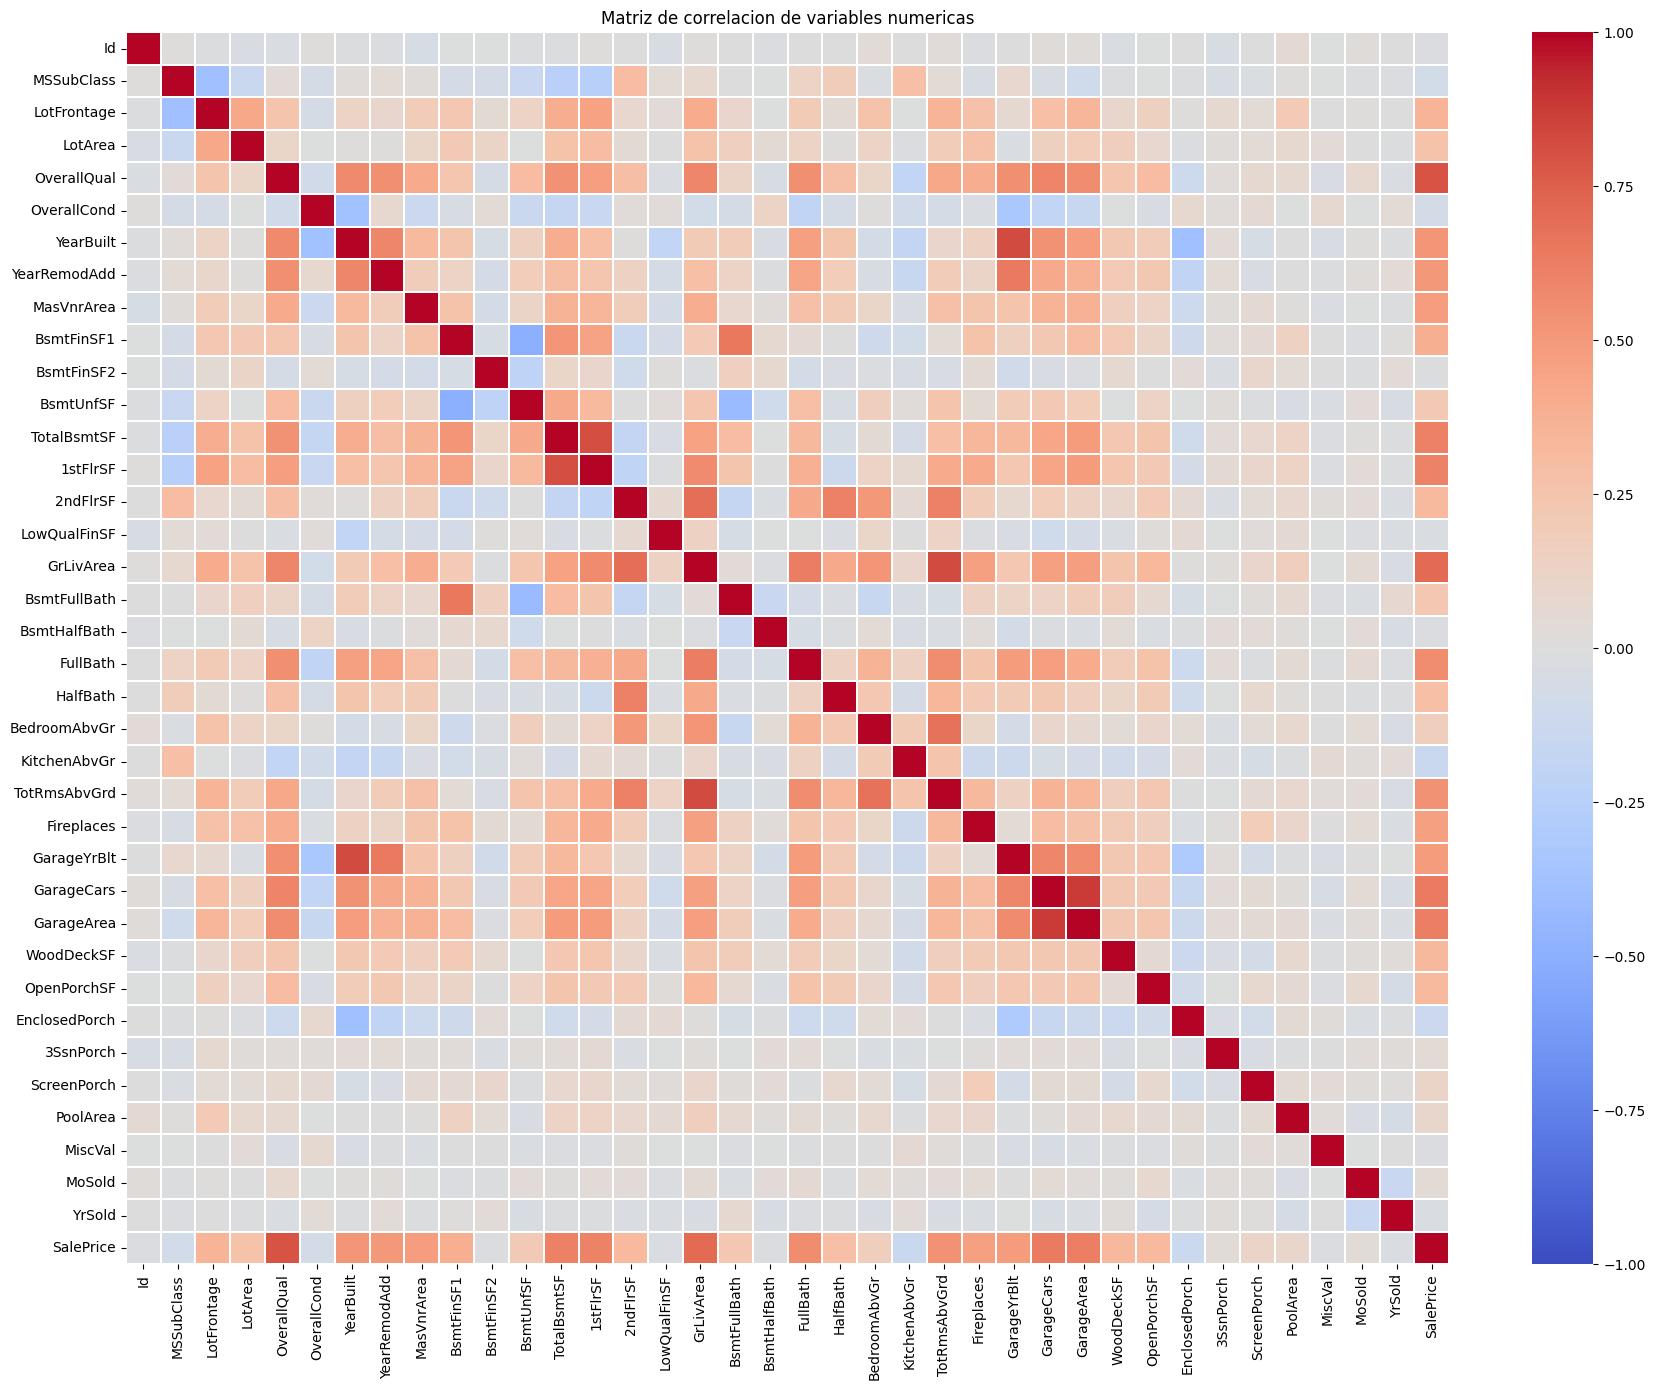

,correlacion_con_SalePrice
SalePrice,1.000000
OverallQual,0.790982
GrLivArea,0.708624
GarageCars,0.640409
GarageArea,0.623431
TotalBsmtSF,0.613581
1stFlrSF,0.605852
FullBath,0.560664
TotRmsAbvGrd,0.533723
YearBuilt,0.522897


In [58]:
import matplotlib.pyplot as plt
import seaborn as sns

correlation_matrix = train_df.select_dtypes(include="number").corr()

plt.figure(figsize=(18, 14))
sns.heatmap(
    correlation_matrix,
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.2
)
plt.title("Matriz de correlacion de variables numericas")
plt.tight_layout()
plt.show()

correlation_with_target = (
    correlation_matrix["SalePrice"]
    .sort_values(ascending=False)
    .to_frame(name="correlacion_con_SalePrice")
 )

correlation_with_target

Se observa inicialmente que hay 13 posibles candidatas a ser variables predictoras por su correlación signficativa

### Correlaciones Variable

Elimino las columnas que tengan baja correlación, ya que no son significativas a mi proceso

In [63]:
low_correlation_vars = correlation_with_target[
    correlation_with_target["correlacion_con_SalePrice"].abs() < 0.6
]
low_correlation_vars


,correlacion_con_SalePrice
FullBath,0.560664
TotRmsAbvGrd,0.533723
YearBuilt,0.522897
YearRemodAdd,0.507101
GarageYrBlt,0.486362
MasVnrArea,0.477493
Fireplaces,0.466929
BsmtFinSF1,0.386420
LotFrontage,0.351799
WoodDeckSF,0.324413


## Matriz Dispersion y distribucion

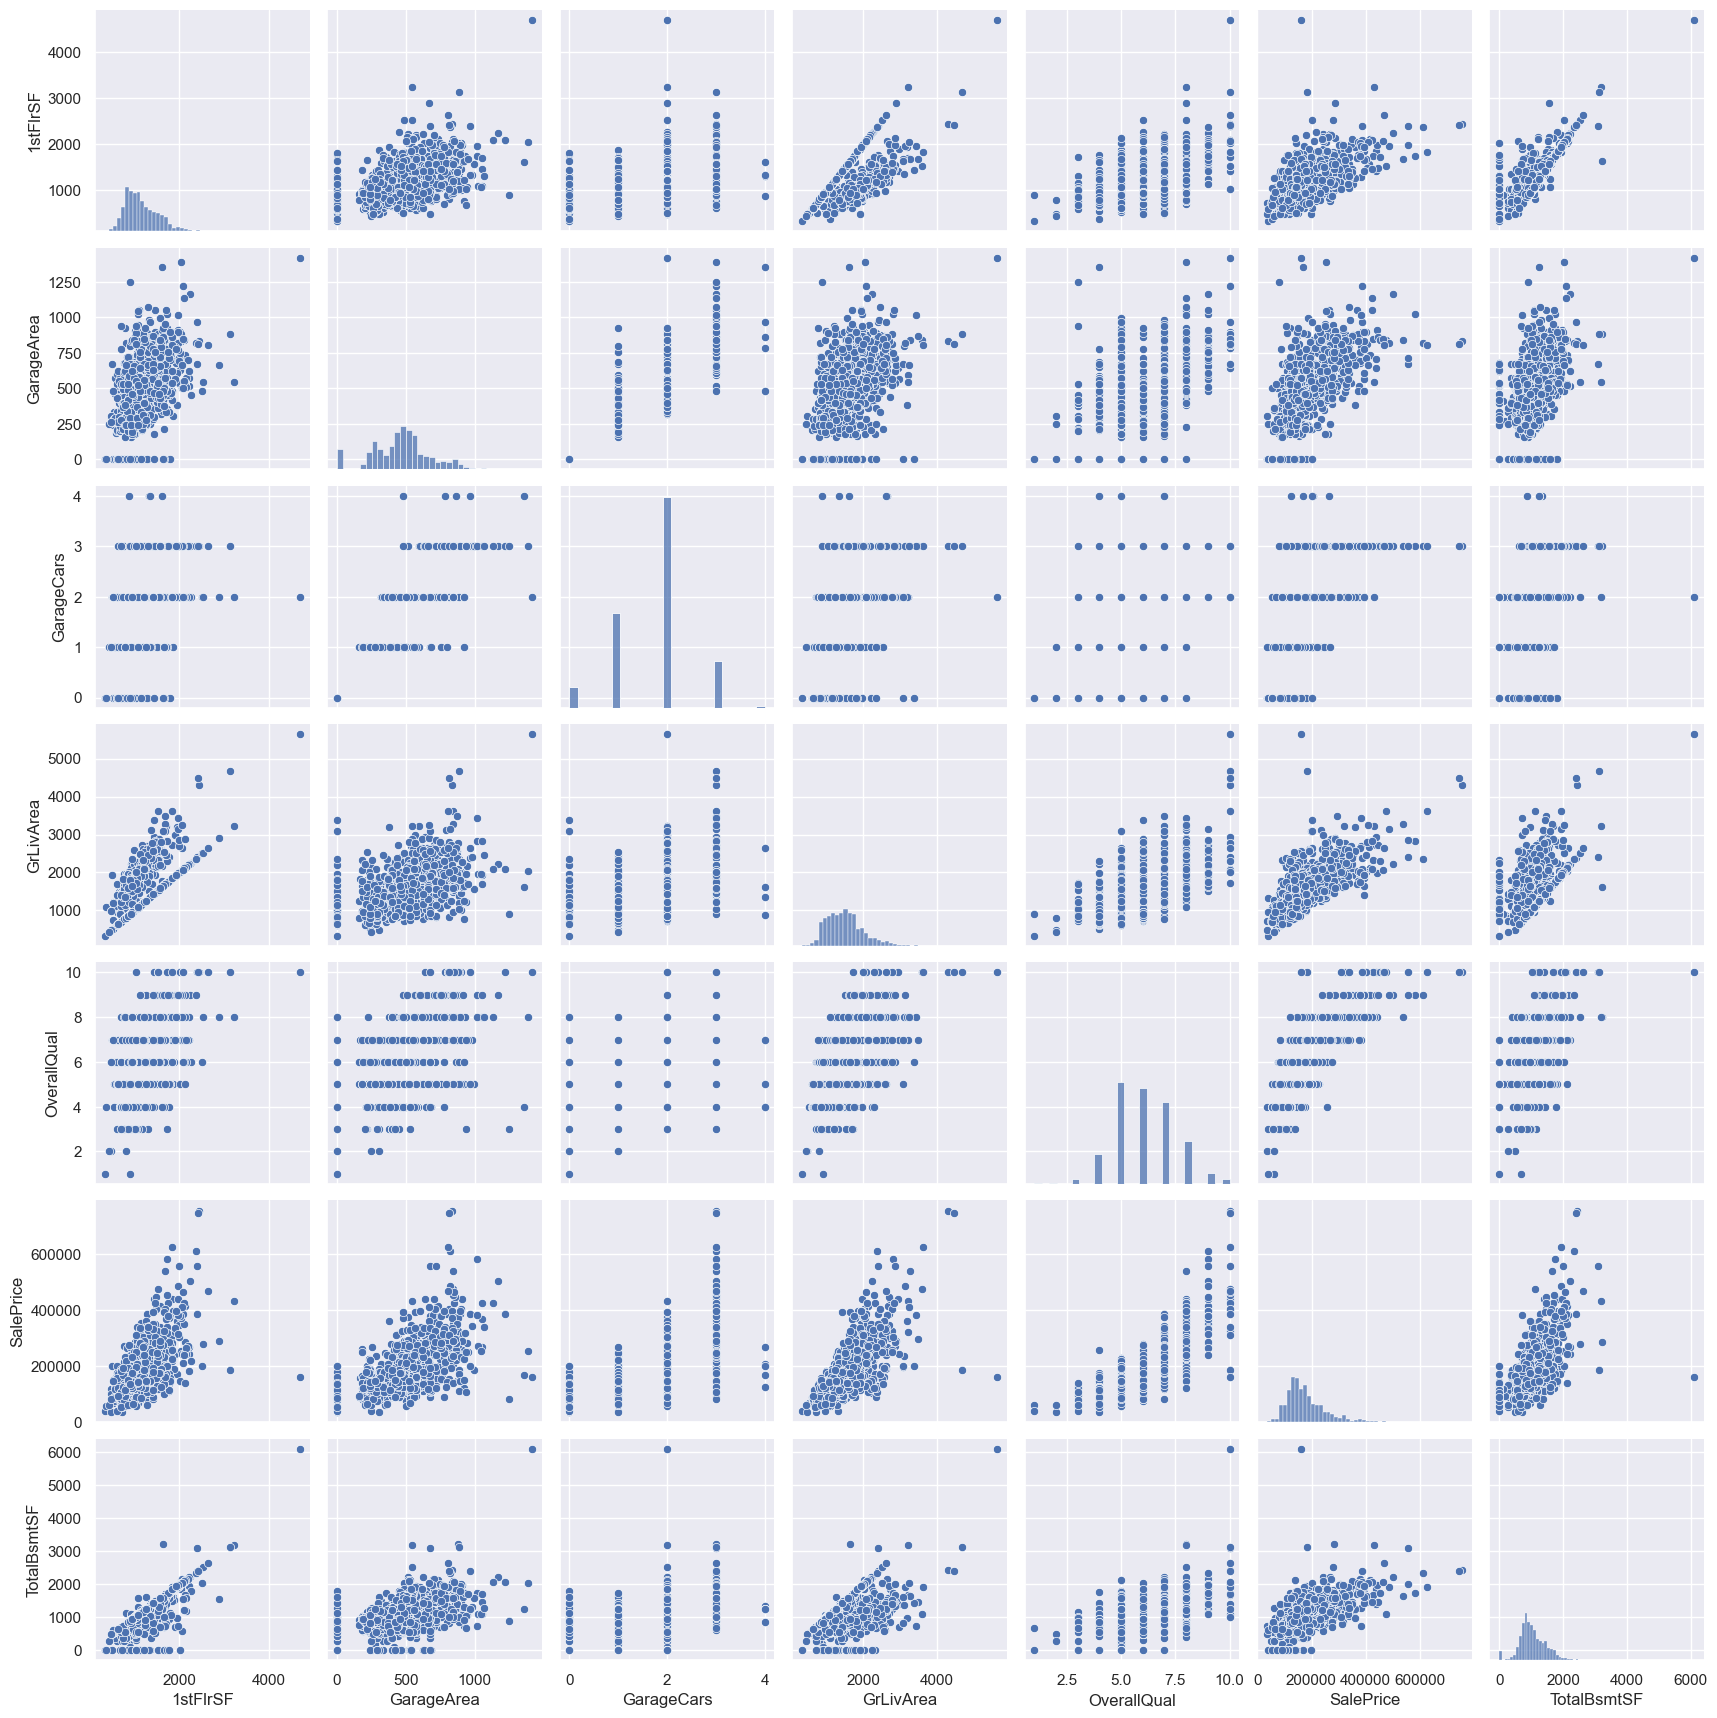

In [64]:
cols = correlation_with_target.index.difference(low_correlation_vars.index).tolist()
sns.set()
sns.pairplot(train_df[cols])


## Retirar puntos Atipicos

## Conversion De Datos Continuos a Categoricos

# Dropeo de Columnas

In [66]:
#1. Elimino las columnas que tienen mas del 40% de datos faltantes, 
# ya que no aportan informacion relevante al modelo y pueden generar ruido en el mismo.
columns_to_drop = [
    "PoolQC",
    "MiscFeature",
    "Alley",
    "Fence",
    "MasVnrType",
    "FireplaceQu",
]

#2. Elimino columnas categoricas que, tras inspeccionar la distribucion de SalePrice
# por categoria, no aportan poder predictivo: son casi constantes o no muestran
# diferencias relevantes en el target entre sus categorias.
columns_to_drop_round2 = {
    "Street": "Se comporta como constante, poca variación en las etiquetas",
    "Utilities": "Se comporta como constante, poca variación en las etiquetas",
    "LotShape": "No hay variaciones significativas en la distribucion de SalePrice",
    "LandContour": "Se comporta como constante, poca variación en las etiquetas",
    "LotConfig": "No hay diferencias significativas en SalePrice",
    "LandSlope": "No hay diferencias significativas en SalePrice",
    "Condition2": "Se comporta como constante, poca variación en las etiquetas",
    "BldgType": "Misma respuesta en SalePrice entre categorias",
    "RoofStyle": "Misma respuesta en SalePrice entre categorias",
    "RoofMatl": "Misma respuesta en SalePrice entre categorias",
    "Exterior1st": "Misma respuesta en SalePrice entre categorias",
    "Exterior2nd": "Misma respuesta en SalePrice entre categorias",
    "ExterCond": "Misma respuesta en SalePrice entre categorias",
    "HouseStyle": "Misma respuesta en SalePrice entre categorias",
    "Foundation": "Misma respuesta en SalePrice entre categorias",
    "BsmtCond": "Misma respuesta en SalePrice entre categorias",
    "BsmtExposure": "Misma respuesta en SalePrice entre categorias",
    "BsmtFinType1": "Misma respuesta en SalePrice entre categorias",
    "BsmtFinType2": "Misma respuesta en SalePrice entre categorias",
    "Heating": "Se comporta como constante, poca variación en las etiquetas",
    "HeatingQC": "Misma respuesta en SalePrice entre categorias",
    "GarageType": "Misma respuesta en SalePrice entre categorias",
    "GarageQual": "Misma respuesta en SalePrice entre categorias",
    "GarageCond": "Misma respuesta en SalePrice entre categorias",
    "PavedDrive": "Misma respuesta en SalePrice / Casi una constante",
    "SaleType": "Misma respuesta en SalePrice entre categorias",
    "SaleCondition": "Misma respuesta en SalePrice entre categorias",
    "Condition1":"Se comporta como constante, poca variación en las etiquetas",
    "Electrical": "Misma respuesta en SalePrice entre categorias",
    "Functional": "Misma respuesta en SalePrice entre categorias",
    "Neighborhood": "Muchas categorias, Posible ruida en la respuesta final",
    "MSZoning": "Misma respuesta en SalePrice entre categorias y poca variación en las etiquetas"
}



train_df_cleaned = train_df.drop(columns=columns_to_drop)
print("Train dataset shape despues del primer drop:", train_df_cleaned.shape)

train_df_cleaned = train_df_cleaned.drop(columns=list(columns_to_drop_round2.keys()))
print("Train dataset shape despues del segundo drop:", train_df_cleaned.shape)


#3. Elimino las variables numericas de baja correlacion con SalePrice
# (definidas en low_correlation_vars), ya que aportan poco poder predictivo al modelo.
train_df_cleaned = train_df_cleaned.drop(columns=low_correlation_vars.index, errors="ignore")
print("Train dataset shape despues de eliminar variables de baja correlacion:", train_df_cleaned.shape)


Train dataset shape despues del primer drop: (1460, 75)
Train dataset shape despues del segundo drop: (1460, 43)
Train dataset shape despues de eliminar variables de baja correlacion: (1460, 12)


## Variables Categoricas Finales

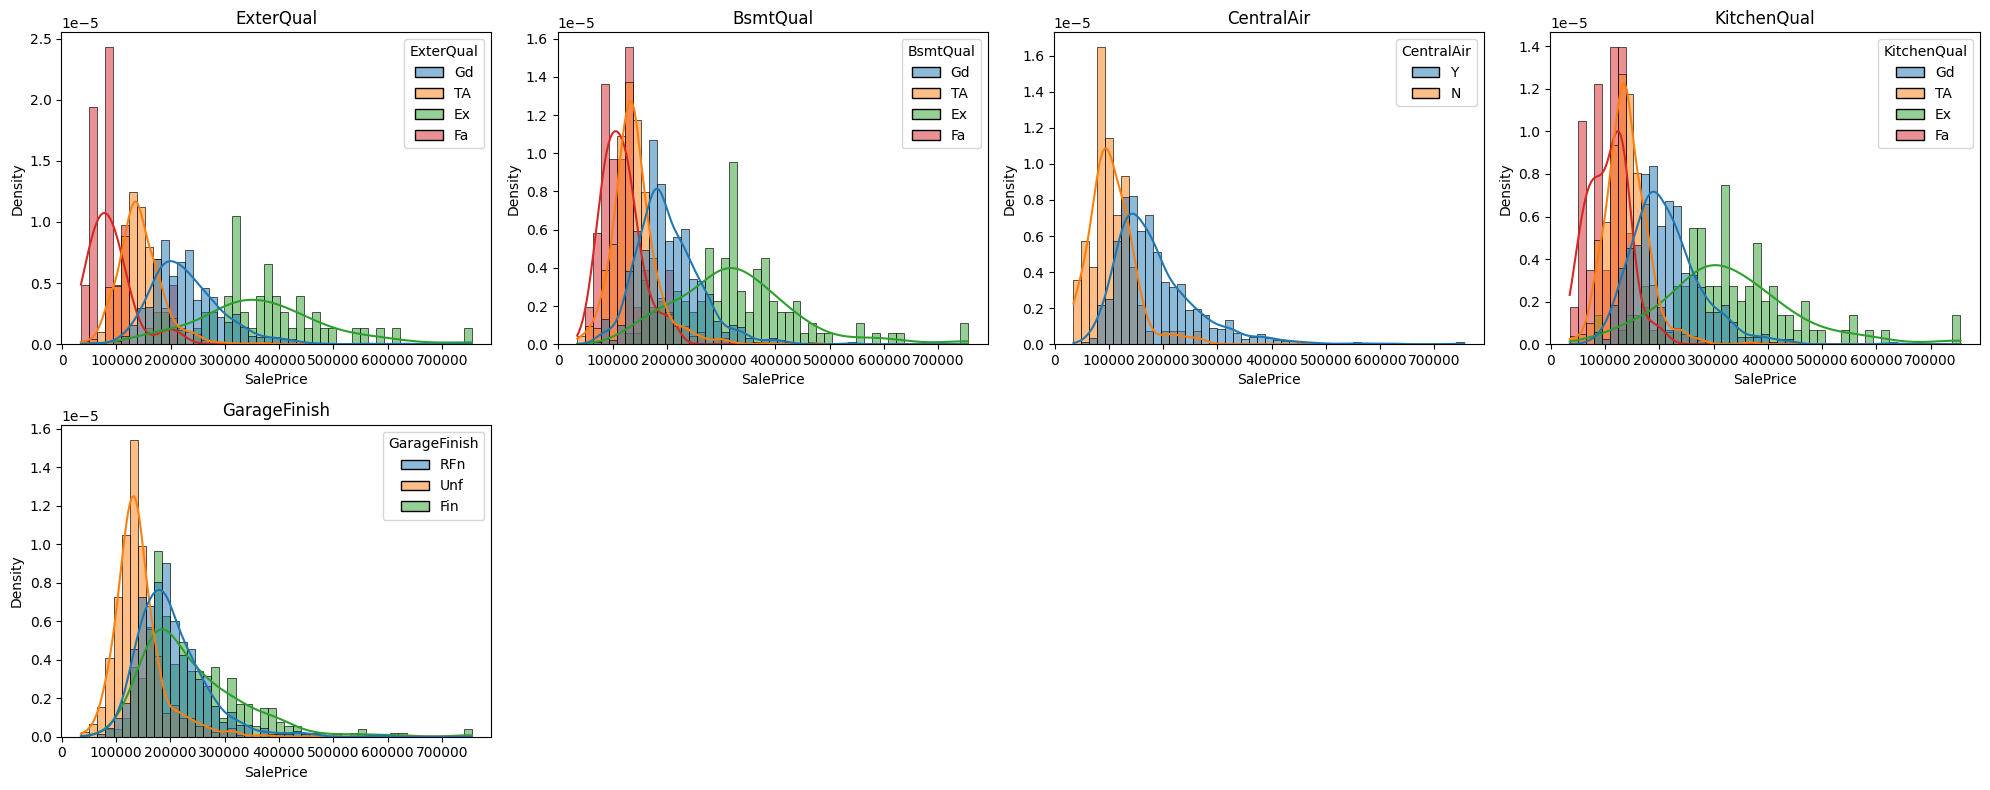

In [56]:

import math
import matplotlib.pyplot as plt
import seaborn as sns

categorical_columns = train_df_cleaned.select_dtypes(include="object").columns.tolist()

n_cols = 4
n_rows = math.ceil(len(categorical_columns) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
axes = axes.flatten()

for ax, column in zip(axes, categorical_columns):
    sns.histplot(
        data=train_df_cleaned,
        x="SalePrice",
        hue=column,
        kde=True,
        stat="density",
        common_norm=False,
        ax=ax,
    )
    ax.set_title(column)

for ax in axes[len(categorical_columns):]:
    fig.delaxes(ax)

plt.tight_layout()
plt.show()


## Variables Continuas Finales

In [ ]:
cols = correlation_with_target.index.difference(low_correlation_vars.index).tolist()
sns.set()
sns.pairplot(train_df[cols])


# Imputación de Datos

In [67]:
train_df_cleaned.info()

missing_summary = (
    train_df_cleaned.isna()
    .sum()
    .to_frame(name="datos_faltantes")
    .assign(
        porcentaje_faltante=lambda dataframe: (
            dataframe["datos_faltantes"] / len(train_df_cleaned) * 100
        ).round(2)
    )
    .sort_values("porcentaje_faltante", ascending=False)
 )

missing_summary[missing_summary["datos_faltantes"] > 0]

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   OverallQual   1460 non-null   int64 
 1   ExterQual     1460 non-null   object
 2   BsmtQual      1423 non-null   object
 3   TotalBsmtSF   1460 non-null   int64 
 4   CentralAir    1460 non-null   object
 5   1stFlrSF      1460 non-null   int64 
 6   GrLivArea     1460 non-null   int64 
 7   KitchenQual   1460 non-null   object
 8   GarageFinish  1379 non-null   object
 9   GarageCars    1460 non-null   int64 
 10  GarageArea    1460 non-null   int64 
 11  SalePrice     1460 non-null   int64 
dtypes: int64(7), object(5)
memory usage: 137.0+ KB


,datos_faltantes,porcentaje_faltante
GarageFinish,81,5.55
BsmtQual,37,2.53


## Garage y BSMNT Ceros como aleatorios entre distribucion normal